In [23]:
!pip install pynwb

In [24]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x135626081162912
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [25]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x135625807442960
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [26]:
from pynwb import NWBHDF5IO

test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# Now call the function
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)
print(f"Test matrix shape: {test_matrix.shape}")

Test matrix shape: (25465, 40)


In [27]:
import numpy as np

def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    # Find the global max time
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
    
    bins = np.arange(0.0, global_max_time + bin_size, bin_size)
    num_bins = len(bins) - 1
    population_matrix = np.zeros((num_bins, num_units))
    
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
    return population_matrix, bins

In [28]:
# Extract trials from the NWB file
# This assumes your NWB file has a 'trials' table
test_trials_df = test_nwbfile.trials.to_dataframe()

# Now you can check the columns to make sure 'start_time' and 'go_time' exist
print(test_trials_df.columns)

Index(['start_time', 'stop_time', 'go_time', 'split'], dtype='object')


In [29]:
# Assuming you want to use the matrix generated from your NWB file
neural_data = test_matrix

In [32]:
import numpy as np
import pandas as pd

# 1. Extract the behavioral trials table from the NWB file
trials_df = nwbfile.intervals['trials'].to_dataframe()

# 2. Filter for valid, non-outlier trials that contain timing information
# We look for 'ready_time' (when the start cue happens) and 'ts' (the target interval length)
valid_trials = trials_df[
    (~trials_df['is_outlier']) & 
    (~trials_df['ready_time'].isna()) & 
    (~trials_df['ts'].isna())
].copy()

# 3. Define a fixed time window around the 'ready_time' to capture the dynamics
# Let's capture 1.5 seconds (75 bins of 20ms) starting exactly at the Ready cue
bin_size = 0.02
window_bins = 75

trial_segments = []
target_intervals = []

for idx, row in valid_trials.iterrows():
    # Convert the start time in seconds to our matrix bin index
    ready_bin = int(row['ready_time'] / bin_size)
    
    # Ensure the window doesn't run past the edge of our recording matrix
    if ready_bin + window_bins < test_matrix.shape[0]:
        # Slice out the (75 bins x 54 neurons) segment for this trial
        segment = test_matrix[ready_bin : ready_bin + window_bins, :]
        trial_segments.append(segment)
        target_intervals.append(row['ts'])

# 4. Stack into a structured 3D population matrix
# Shape: (Number of Trials x 75 Time Steps x 54 Neurons)
lfads_input = np.array(trial_segments)
trial_conditions = np.array(target_intervals)

print(" HYPOTHESIS TESTING DATASET PREPARED")
print(f"Total structured trials extracted: {lfads_input.shape[0]}")
print(f"Array shape: {lfads_input.shape} (Trials x Time Bins x Neurons)")

 HYPOTHESIS TESTING DATASET PREPARED
Total structured trials extracted: 110
Array shape: (110, 75, 40) (Trials x Time Bins x Neurons)


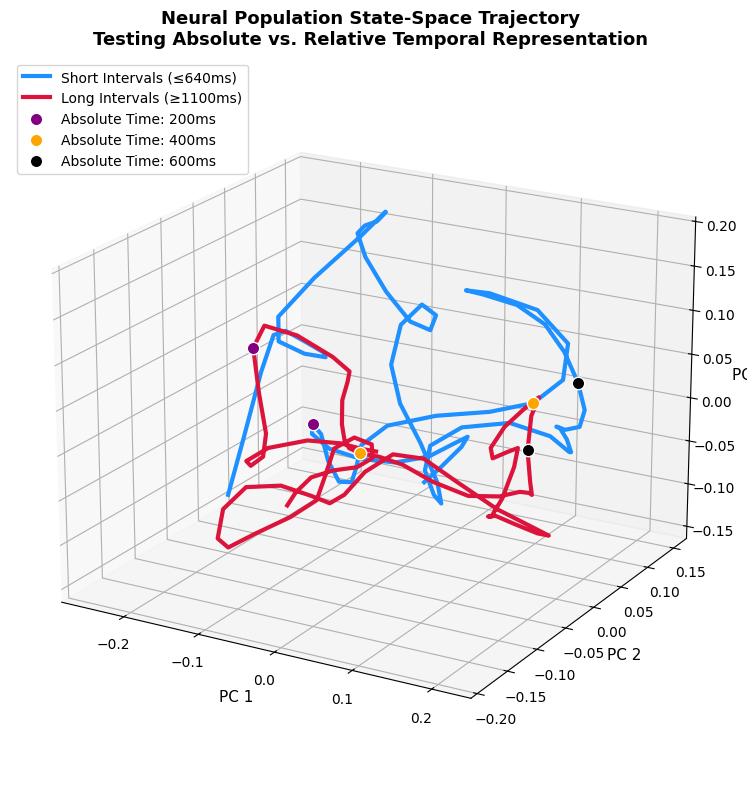

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler

raw_3d_data = create_3d_trial_data(test_matrix, test_trials_df, bin_size=0.02, window_duration=1.0)

smoothed_input = gaussian_filter1d(lfads_input.astype(float), sigma=1.5, axis=1)


q25 = np.percentile(trial_conditions, 25)
q75 = np.percentile(trial_conditions, 75)

short_idx = np.where(trial_conditions <= q25)[0]
long_idx = np.where(trial_conditions >= q75)[0]


mean_short_pop = np.mean(smoothed_input[short_idx, :, :], axis=0)
mean_long_pop = np.mean(smoothed_input[long_idx, :, :], axis=0)


combined_pop = np.vstack([mean_short_pop, mean_long_pop])

scaler = StandardScaler()
scaled_pop = scaler.fit_transform(combined_pop)

pca = PCA(n_components=3)
pca.fit(combined_pop)

scaled_short = scaler.transform(mean_short_pop)
scaled_long = scaler.transform(mean_long_pop)

# Transform both trajectories into the same 3D neural state space
proj_short = pca.transform(mean_short_pop)
proj_long = pca.transform(mean_long_pop)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the continuous trajectory paths
ax.plot(proj_short[:, 0], proj_short[:, 1], proj_short[:, 2], 
        color='dodgerblue', linewidth=3, label=f'Short Intervals (≤{q25:.0f}ms)')
ax.plot(proj_long[:, 0], proj_long[:, 1], proj_long[:, 2], 
        color='crimson', linewidth=3, label=f'Long Intervals (≥{q75:.0f}ms)')


time_markers = [10, 20, 30]
colors = ['purple', 'orange', 'black']

for idx, t_step in enumerate(time_markers):
    # Short trial marker
    ax.scatter(proj_short[t_step, 0], proj_short[t_step, 1], proj_short[t_step, 2], 
               color=colors[idx], s=80, edgecolor='w', zorder=10)
    # Long trial marker
    ax.scatter(proj_long[t_step, 0], proj_long[t_step, 1], proj_long[t_step, 2], 
               color=colors[idx], s=80, edgecolor='w', zorder=10, 
               label=f'Absolute Time: {t_step*20}ms' if idx==0 or idx==1 or idx==2 else "")

# Visual styling
ax.set_xlabel('PC 1', fontsize=11, labelpad=5)
ax.set_ylabel('PC 2', fontsize=11, labelpad=5)
ax.set_zlabel('PC 3', fontsize=11, labelpad=5)
ax.set_title('Neural Population State-Space Trajectory\nTesting Absolute vs. Relative Temporal Representation', fontsize=13, weight='bold', pad=10)
ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()